In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)


In [3]:
# df = pd.read_csv('auto_imports.csv')

In [4]:
# df.info()

In [5]:
# df.head(5)

### Adding column

In [6]:
columns = [
    'symboling', 'normalized_losses', 'make', 'fuel_type', 'aspiration', 'num_of_doors', 'body_style', 'drive_wheels',
    'engine_location', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_type', 'num_of_cylinders',
    'engine_size', 'fuel_system', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 
    'highway_mpg', 'price'
]

In [7]:
# since there is no column so header is set to None so first row will not be treated 
# as header
# And names mean what are define column Name

df = pd.read_csv('auto_imports.csv', header = None, names = columns, na_values = ['?'])
df.head(5)

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


In [8]:
df.isnull().sum()

symboling             0
normalized_losses    37
make                  0
fuel_type             0
aspiration            0
num_of_doors          2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_of_cylinders      0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 0
dtype: int64

Text(0.5, 1.0, 'Missing Data Heatmpa')

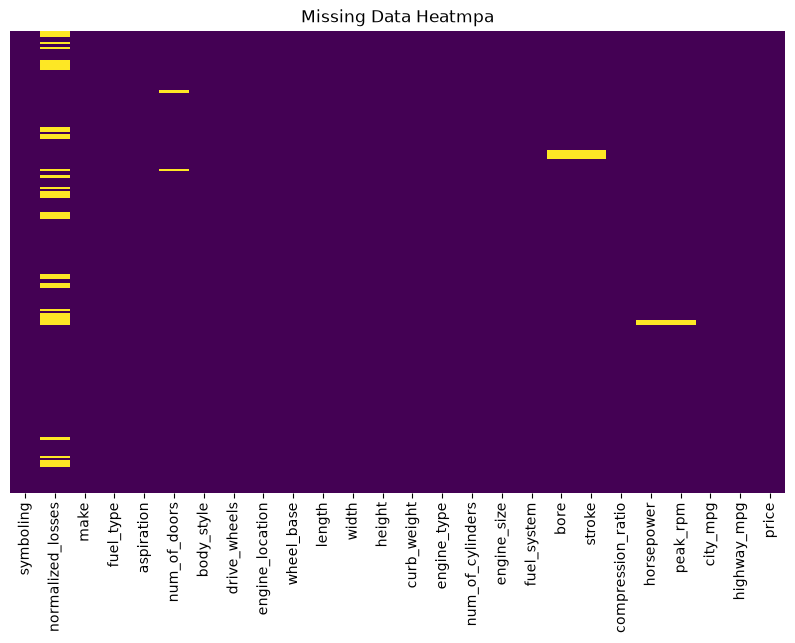

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), yticklabels=False, cbar = False, cmap='viridis')
plt.title("Missing Data Heatmpa")


### Univariate Analysis

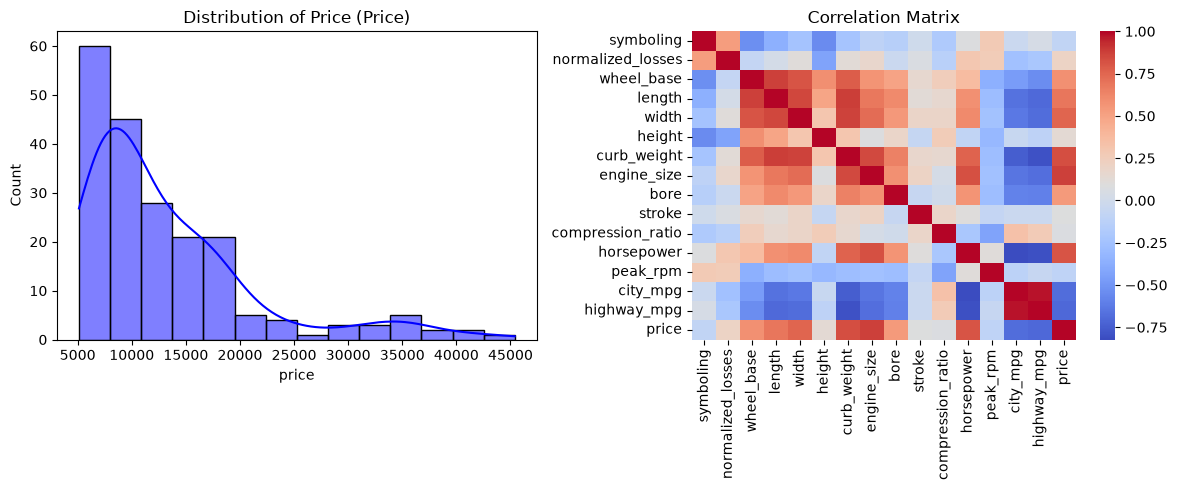

In [10]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
sns.histplot(df['price'].dropna(), kde = True, color='blue')
plt.title('Distribution of Price (Price)')

plt.subplot(1,2,2)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap= 'coolwarm')
plt.title('Correlation Matrix')

plt.tight_layout()

In [11]:
# in 'num-of-cylinders' column the data are in two four instead of 2 4 
# change two --> 2
# using mapping
word_to_num = {
    "two" : 2, "three" : 3, "four" : 4 , "five" : 5 , "six" : 6, "eight" : 8, "twelve" : 12
}

df["num_of_cylinders"] = df["num_of_cylinders"].map(word_to_num)

In [12]:
df.head(2)

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500


### Converting two four into 2 4 in num_of_doors

In [13]:
# filling NaN in num of door column 
mode_by_style = df.groupby('body_style')['num_of_doors'].agg(
    lambda s: s.mode().iat[0] if not s.mode().empty else np.nan
)
df['num_of_doors'] = df.apply(
    lambda r: mode_by_style[r['body_style']] if pd.isnull(r['num_of_doors']) else r['num_of_doors']
    ,axis = 1
)
door_map = {"two": 2, "four": 4}
df["num_of_doors"] = df["num_of_doors"].map(door_map)




In [14]:
for c in ['normalized_losses', 'price', 'peak_rpm', 'horsepower', 'bore','stroke']:
    df[c] = df[c].fillna(df[c].median())

In [15]:
df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,115.0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,115.0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,115.0,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,6,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,4,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,4,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,4,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,5,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized_losses  201 non-null    float64
 2   make               201 non-null    str    
 3   fuel_type          201 non-null    str    
 4   aspiration         201 non-null    str    
 5   num_of_doors       201 non-null    int64  
 6   body_style         201 non-null    str    
 7   drive_wheels       201 non-null    str    
 8   engine_location    201 non-null    str    
 9   wheel_base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb_weight        201 non-null    int64  
 14  engine_type        201 non-null    str    
 15  num_of_cylinders   201 non-null    int64  
 16  engine_size        201 non-null    in

### changing data type to correct dtype

In [17]:
numeric_dtype = ['normalized_losses', 'peak_rpm', 'horsepower']

for c in numeric_dtype:
    df[c] = pd.to_numeric(df[c], errors= "coerce")
    df[c] = df[c].astype("int64")

In [18]:
df.head(5)

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,115,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,115,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,115,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,6,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,4,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,4,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,4,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,5,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [19]:
df.iloc[60:66]

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
60,0,115,mazda,diesel,std,4,sedan,fwd,front,98.8,177.8,66.5,55.5,2443,ohc,4,122,idi,3.39,3.39,22.7,64,4650,36,42,10795
61,0,115,mazda,gas,std,4,hatchback,fwd,front,98.8,177.8,66.5,55.5,2425,ohc,4,122,2bbl,3.39,3.39,8.6,84,4800,26,32,11245
62,0,118,mazda,gas,std,4,sedan,rwd,front,104.9,175.0,66.1,54.4,2670,ohc,4,140,mpfi,3.76,3.16,8.0,120,5000,19,27,18280
63,0,115,mazda,diesel,std,4,sedan,rwd,front,104.9,175.0,66.1,54.4,2700,ohc,4,134,idi,3.43,3.64,22.0,72,4200,31,39,18344
64,-1,93,mercedes-benz,diesel,turbo,4,sedan,rwd,front,110.0,190.9,70.3,56.5,3515,ohc,5,183,idi,3.58,3.64,21.5,123,4350,22,25,25552
65,-1,93,mercedes-benz,diesel,turbo,4,wagon,rwd,front,110.0,190.9,70.3,58.7,3750,ohc,5,183,idi,3.58,3.64,21.5,123,4350,22,25,28248


In [20]:
df.isnull().sum().sum()

np.int64(0)

### Till here all empty cell are filled and null value is zero

### Outlier

#### will work outlier later

### Train Test Split

In [21]:
x = df.drop('price', axis = 1)
y = df['price']

In [22]:
display(x)
display(y)

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,height,curb_weight,engine_type,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg
0,3,115,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111,5000,21,27
1,3,115,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111,5000,21,27
2,1,115,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,6,152,mpfi,2.68,3.47,9.0,154,5000,19,26
3,2,164,audi,gas,std,4,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,4,109,mpfi,3.19,3.40,10.0,102,5500,24,30
4,2,164,audi,gas,std,4,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,5,136,mpfi,3.19,3.40,8.0,115,5500,18,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95,volvo,gas,std,4,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,4,141,mpfi,3.78,3.15,9.5,114,5400,23,28
197,-1,95,volvo,gas,turbo,4,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,4,141,mpfi,3.78,3.15,8.7,160,5300,19,25
198,-1,95,volvo,gas,std,4,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,6,173,mpfi,3.58,2.87,8.8,134,5500,18,23
199,-1,95,volvo,diesel,turbo,4,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,6,145,idi,3.01,3.40,23.0,106,4800,26,27


0      13495
1      16500
2      16500
3      13950
4      17450
       ...  
196    16845
197    19045
198    21485
199    22470
200    22625
Name: price, Length: 201, dtype: int64

In [23]:
numerical_column = x.select_dtypes(include = np.number).columns.to_list()
display(numerical_column)

['symboling',
 'normalized_losses',
 'num_of_doors',
 'wheel_base',
 'length',
 'width',
 'height',
 'curb_weight',
 'num_of_cylinders',
 'engine_size',
 'bore',
 'stroke',
 'compression_ratio',
 'horsepower',
 'peak_rpm',
 'city_mpg',
 'highway_mpg']

In [24]:
categorical_column = x.select_dtypes(exclude= np.number).columns.to_list()
display(categorical_column)

['make',
 'fuel_type',
 'aspiration',
 'body_style',
 'drive_wheels',
 'engine_location',
 'engine_type',
 'fuel_system']

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state= 42)

### Standard scalers

In [26]:
scaler = StandardScaler()

x_train_scaler = scaler.fit_transform(x_train[numerical_column])
x_test_scaler = scaler.transform(x_test[numerical_column])

In [27]:
display(x_train_scaler)
display(x_test_scaler)

array([[-1.43486011, -0.77616889,  0.80590603, ...,  0.77645019,
        -1.15657364, -1.16471216],
       [-0.61494005, -1.08371476,  0.80590603, ...,  1.40706964,
         0.27056093,  0.33451508],
       [ 0.20498002,  0.85382423,  0.80590603, ...,  0.77645019,
         0.90484296,  1.08412869],
       ...,
       [ 0.20498002,  0.23873248, -1.24083945, ...,  0.14583075,
         0.90484296,  0.93420597],
       [ 1.02490008,  0.05420496, -1.24083945, ...,  0.25093399,
         0.27056093,  0.4844378 ],
       [ 1.84482014,  2.26853524, -1.24083945, ...,  0.14583075,
        -1.31514415, -1.16471216]], shape=(160, 17))

array([[ 1.02490008,  1.46891597, -1.24083945, -0.62038501, -0.96888139,
        -0.9957769 , -0.21953574, -1.08387091, -0.30855869, -0.69861044,
        -0.63853104,  0.12511517, -0.16292518, -0.92026899,  0.14583075,
         0.90484296,  0.93420597],
       [-0.61494005, -0.16107715, -1.24083945,  0.80417923,  1.64828087,
         1.04556575, -0.05635006,  1.71413632,  1.62749582,  2.12737129,
         1.0862367 ,  0.43888364, -0.53604899,  2.24956591,  0.56624371,
        -1.47371466, -1.31463488],
       [ 1.02490008,  0.51552377, -1.24083945, -2.06190834, -2.45249566,
        -0.94598806, -1.23944626, -1.46931069, -0.30855869, -0.82477034,
        -1.5192635 ,  0.50163733, -0.21622858, -0.72390754,  1.8274826 ,
         0.90484296,  1.08412869],
       [-0.61494005, -0.89918724,  0.80590603, -0.51863042, -0.64381983,
        -0.69704383, -0.42351784, -0.81467488, -0.30855869, -0.67337846,
        -0.49174229, -0.69068283, -0.26953198, -0.89221736, -0.69499518,
         0.42913144

### Feature Encoding

In [28]:
df[numerical_column].corr()

,symboling,normalized_losses,num_of_doors,wheel_base,length,width,height,curb_weight,num_of_cylinders,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg
symboling,1.000000,0.457735,-0.672344,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.118016,-0.110581,-0.142547,-0.004387,-0.182196,0.075486,0.279897,-0.035527,0.036233
normalized_losses,0.457735,1.000000,-0.355303,-0.075109,-0.009116,0.061799,-0.371830,0.065393,0.080549,0.073586,-0.052094,0.046024,-0.115967,0.182479,0.245899,-0.193896,-0.150773
num_of_doors,-0.672344,-0.355303,1.000000,0.445245,0.395122,0.227655,0.538383,0.208517,0.002225,0.024094,0.120915,-0.010194,0.169164,-0.102504,-0.232247,-0.027617,-0.045787
wheel_base,-0.535987,-0.075109,0.445245,1.000000,0.876024,0.814507,0.590742,0.782097,0.348931,0.572027,0.494065,0.156740,0.250313,0.372156,-0.360946,-0.470606,-0.543304
length,-0.365404,-0.009116,0.395122,0.876024,1.000000,0.857170,0.492063,0.880665,0.440348,0.685025,0.609557,0.123016,0.159733,0.578683,-0.285301,-0.665192,-0.698142
width,-0.242423,0.061799,0.227655,0.814507,0.857170,1.000000,0.306002,0.866201,0.520118,0.729436,0.544986,0.188605,0.189867,0.614146,-0.245273,-0.633531,-0.680635
height,-0.550160,-0.371830,0.538383,0.590742,0.492063,0.306002,1.000000,0.307581,0.007776,0.074694,0.182946,-0.064380,0.259737,-0.086078,-0.310513,-0.049800,-0.104812
curb_weight,-0.233118,0.065393,0.208517,0.782097,0.880665,0.866201,0.307581,1.000000,0.604454,0.849072,0.644434,0.166809,0.156433,0.757961,-0.279429,-0.749543,-0.794889
num_of_cylinders,-0.118016,0.080549,0.002225,0.348931,0.440348,0.520118,0.007776,0.604454,1.000000,0.847639,0.205936,0.008480,-0.018138,0.669385,-0.152422,-0.439432,-0.473746
engine_size,-0.110581,0.073586,0.024094,0.572027,0.685025,0.729436,0.074694,0.849072,0.847639,1.000000,0.574504,0.203043,0.028889,0.822167,-0.256503,-0.650546,-0.679571


* converting categorical column into Numerical Column

In [29]:
encoding = OneHotEncoder()

In [30]:
x_train_OneHotEnc = encoding.fit_transform(x_train[categorical_column])
x_test_OneHotEnc = encoding.transform(x_test[categorical_column])

In [31]:
display(pd.DataFrame(x_train_OneHotEnc))

,0
0,<Compressed Sparse Row sparse matrix of dtype ...
1,<Compressed Sparse Row sparse matrix of dtype ...
2,<Compressed Sparse Row sparse matrix of dtype ...
3,<Compressed Sparse Row sparse matrix of dtype ...
4,<Compressed Sparse Row sparse matrix of dtype ...
...,...
155,<Compressed Sparse Row sparse matrix of dtype ...
156,<Compressed Sparse Row sparse matrix of dtype ...
157,<Compressed Sparse Row sparse matrix of dtype ...
158,<Compressed Sparse Row sparse matrix of dtype ...


the above data are in 0 dimensional , this is wrong . data did not spread in array

so applying sparse_output = False

In [32]:
encoding = OneHotEncoder(handle_unknown= 'ignore', sparse_output=False)


In [33]:
# doing once 

x_train_OneHotEnc = encoding.fit_transform(x_train[categorical_column])
x_test_OneHotEnc = encoding.transform(x_test[categorical_column])

In [34]:
display(pd.DataFrame(x_train_OneHotEnc))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
156,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
157,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
158,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### Combining x_train scaler and x_train Encoding to make final

In [35]:
x_train_final = np.hstack([x_train_scaler, x_train_OneHotEnc])
x_test_final = np.hstack([x_test_scaler, x_test_OneHotEnc])

In [36]:
print(x_train_final.shape)
print(x_test_final.shape)

(160, 67)
(41, 67)


### [x_train_final & x_test_final ] ..is the final data for x_train


### Model Building

In [37]:
models = {
    'AdaBoost Regressor' : AdaBoostRegressor(),
    'CatBoosting Regressor' : CatBoostRegressor(verbose = False),
    'Decision Tree' : DecisionTreeRegressor(),
    'K-Neighbors Regressor' : KNeighborsRegressor(),
    'Lasso' : Lasso(),
    'Linear Regression' : LinearRegression(),
    'Random Forest Regressor' : RandomForestRegressor(),
    'Ridge' :Ridge(),
    'XGBRegressor' : XGBRegressor()
}

In [38]:
# defining evaluation matrics

def evaluation(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [39]:
model_list = []
r2_list = []
pred_list = {}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train_final, y_train)

    
    y_train_pred = model.predict(x_train_final)
    y_test_pred = model.predict(x_test_final)


    model_train_mae, model_train_rmse, model_train_r2 = evaluation(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluation(y_test, y_test_pred)


    print('----------------------------------')
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    print('----------------------------------')

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))


    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)


----------------------------------
AdaBoost Regressor
----------------------------------
Model performance for Training set
- Root Mean Squared Error: 1558.9942
- Mean Absolute Error: 1319.3023
- R2 Score: 0.9467
Model performance for Test set
- Root Mean Squared Error: 2979.6383
- Mean Absolute Error: 2278.9303
- R2 Score: 0.9274
----------------------------------
CatBoosting Regressor
----------------------------------
Model performance for Training set
- Root Mean Squared Error: 372.4481
- Mean Absolute Error: 271.3509
- R2 Score: 0.9970
Model performance for Test set
- Root Mean Squared Error: 3082.3202
- Mean Absolute Error: 1907.2064
- R2 Score: 0.9223
----------------------------------
Decision Tree
----------------------------------
Model performance for Training set
- Root Mean Squared Error: 215.3915
- Mean Absolute Error: 47.6375
- R2 Score: 0.9990
Model performance for Test set
- Root Mean Squared Error: 3082.5233
- Mean Absolute Error: 2061.9512
- R2 Score: 0.9223
--------

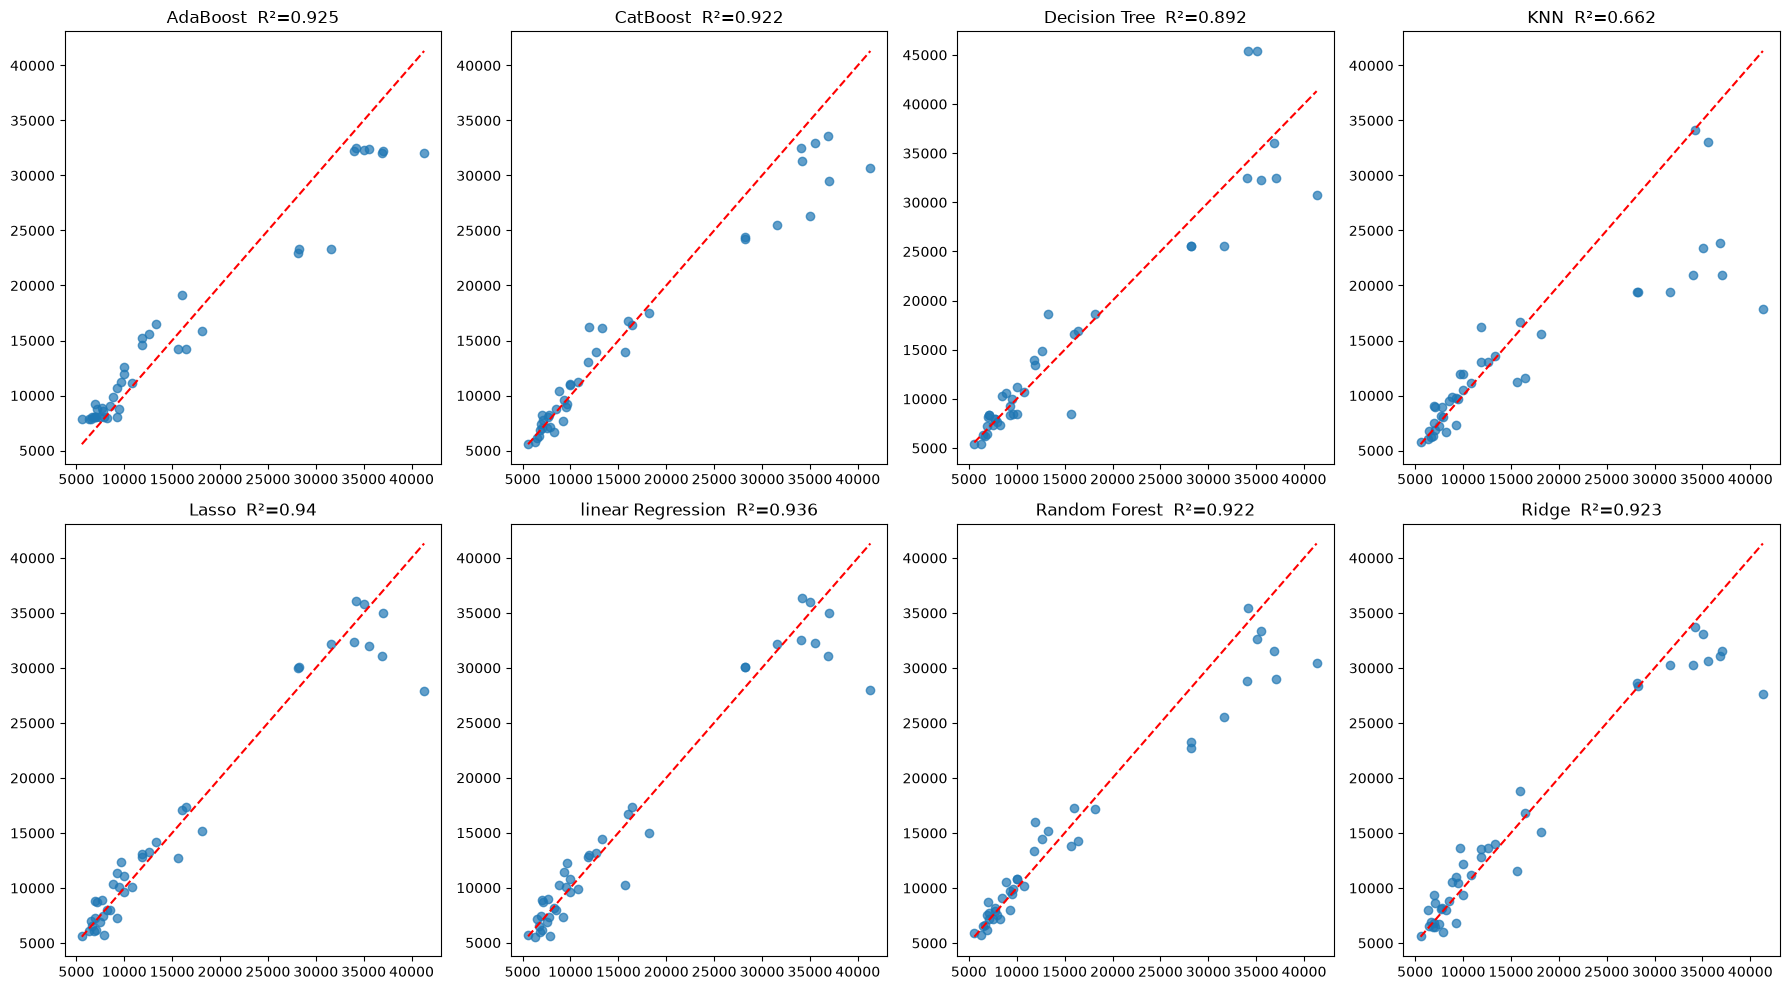

In [40]:
plot_model = {
    "AdaBoost"      : AdaBoostRegressor(),
    "CatBoost"      : CatBoostRegressor(verbose=False),
    "Decision Tree" : DecisionTreeRegressor(),
    "KNN"           : KNeighborsRegressor(),
    "Lasso"         : Lasso(),
    "linear Regression" : LinearRegression(),
    "Random Forest" : RandomForestRegressor(),
    "Ridge"         : Ridge(),
    "XGBRegressor"  : XGBRegressor(),
}

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()


for ax, (name, model) in zip(axes, plot_model.items()):
    model.fit(x_train_final, y_train)
    preds = model.predict(x_test_final)
    r2    = round(r2_score(y_test, preds), 3)

    ax.scatter(y_test, preds, alpha=0.7)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], "r--")
    ax.set_title(f"{name}  R²={r2}")

plt.tight_layout()
plt.show()

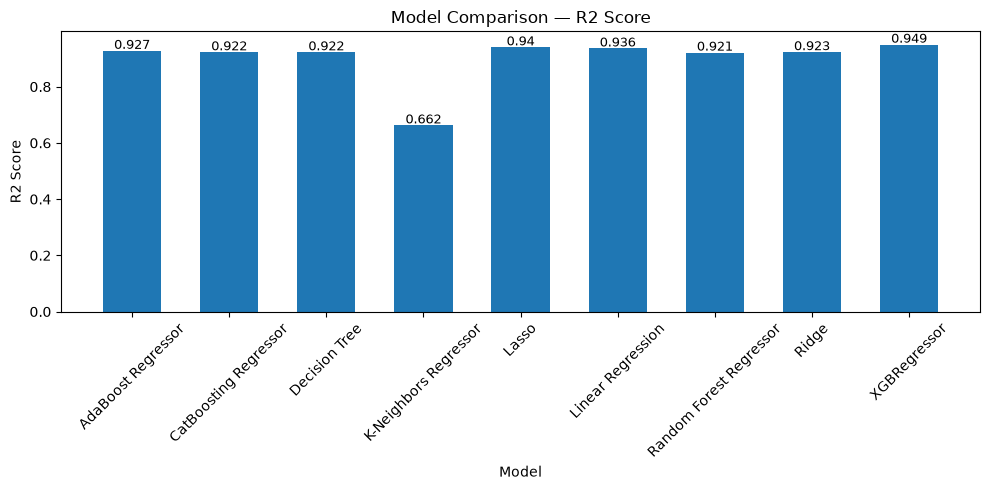

In [41]:
clean_models = [(m, r) for m, r in zip(model_list, r2_list)]

plt.figure(figsize=(10, 5))
bars = plt.bar([m for m, r in clean_models], 
                [r for m, r in clean_models],width=0.6 )

for bar, (m, r) in zip(bars, clean_models):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.007,
             str(round(r, 3)), 
             ha="center", fontsize=9)



plt.title("Model Comparison — R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Cross-Validation

In [42]:
cv_score={}
for name, model in plot_model.items():
    scores = cross_val_score(model, x_train_final, y_train, cv=5, scoring="r2")
    print(f"{name:20s}  CV R2: {round(scores.mean(), 3)}  Std: {round(scores.std(), 3)}")
    cv_score[name] = round(scores.mean(), 3)
    

AdaBoost              CV R2: 0.839  Std: 0.056
CatBoost              CV R2: 0.861  Std: 0.048
Decision Tree         CV R2: 0.773  Std: 0.066
KNN                   CV R2: 0.751  Std: 0.086
Lasso                 CV R2: 0.817  Std: 0.056
linear Regression     CV R2: 0.825  Std: 0.044
Random Forest         CV R2: 0.859  Std: 0.054
Ridge                 CV R2: 0.859  Std: 0.039
XGBRegressor          CV R2: 0.809  Std: 0.073


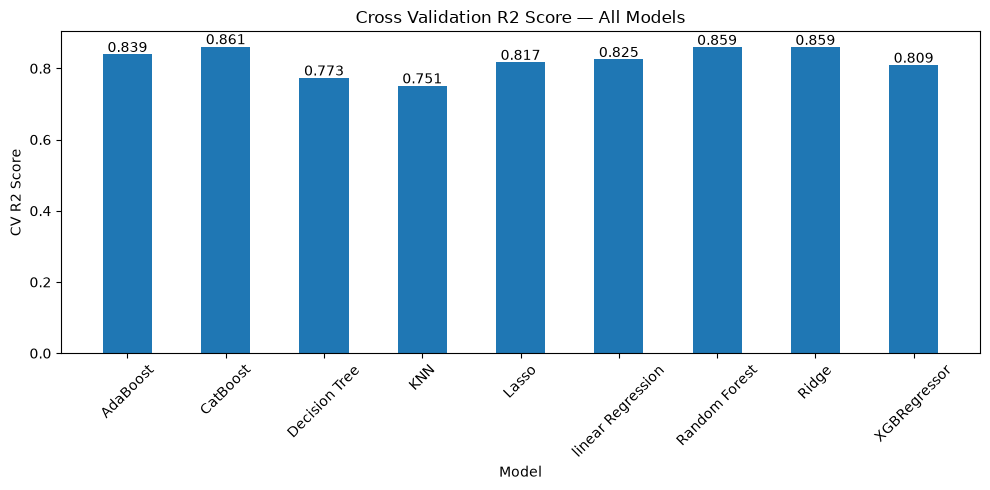

In [43]:
plt.figure(figsize=(10, 5))
plt.bar(cv_score.keys(), cv_score.values(), width=0.5)

for i, (name, score) in enumerate(cv_score.items()):
    plt.text(i, score + 0.007, str(score), ha="center", fontsize=10)
    

plt.title("Cross Validation R2 Score — All Models")
plt.xlabel("Model")
plt.ylabel("CV R2 Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Hyperparameter Tuning

Performing Hyperparameter tuning on **all** model.

In [44]:
from sklearn.model_selection import GridSearchCV

In [45]:
param_grid = {
    "AdaBoost" : (
        AdaBoostRegressor(),
        {
            "n_estimators" : [50, 100, 200],
            "learning_rate" : [0.01, 0.1, 0.5, 1.0],
        }
    ),
    'CatBoost' : (
        CatBoostRegressor(verbose = False),
        {
            'iterations' : [500, 1000, 1500],
            'learning_rate' : [0.01, 0.3, 0.1],
            'depth': [4,6,8]
        }
    ),
    'Decision Tree' : (
        DecisionTreeRegressor(),
        {
            'max_depth' : [3, 5, 7, 10],
            'min_samples_split' : [2,5,10]
        }
    ),
    "KNN" : (
        KNeighborsRegressor(),
        {
            'n_neighbors' : [3, 5, 7, 10],
            'weights' : ['uniform', 'distance'],
        }
    ),
    'Lasso' : (
        Lasso(max_iter = 100000, tol=0.01),
        {
            'alpha' : [0.001, 0.01, 0.1, 1.0, 10.0],
        }
    ),
    'Linear' : (
        LinearRegression(),
        {
            'fit_intercept' : [True, False],
            'positive'      : [True, False],
        }
    ),
    "Ridge": (
        Ridge(),
        {
            "alpha": [0.1, 1.0, 10.0, 100.0],
        }
    ),
    "XGBoost": (
        XGBRegressor(),
        {
            "n_estimators" : [100, 300, 500],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth"    : [3, 5, 7],
        }
    ),
}

In [46]:
best_models = {}

for name, (model, params) in param_grid.items():
    grid = GridSearchCV(model, params, cv=5, scoring="r2", n_jobs=-1)
    grid.fit(x_train_final, y_train)

    best_models[name] = grid.best_estimator_

    preds  = grid.best_estimator_.predict(x_test_final)
    test_r2 = round(r2_score(y_test, preds), 3)

    print(f"── {name} ──")
    print(f"Best Params : {grid.best_params_}")
    print(f"Best CV R2  : {round(grid.best_score_, 3)}")
    print(f"Test R2     : {test_r2}")
    print()

── AdaBoost ──
Best Params : {'learning_rate': 0.5, 'n_estimators': 50}
Best CV R2  : 0.847
Test R2     : 0.928

── CatBoost ──
Best Params : {'depth': 4, 'iterations': 1500, 'learning_rate': 0.01}
Best CV R2  : 0.878
Test R2     : 0.932

── Decision Tree ──
Best Params : {'max_depth': 7, 'min_samples_split': 2}
Best CV R2  : 0.829
Test R2     : 0.887

── KNN ──
Best Params : {'n_neighbors': 3, 'weights': 'distance'}
Best CV R2  : 0.783
Test R2     : 0.756

── Lasso ──
Best Params : {'alpha': 10.0}
Best CV R2  : 0.846
Test R2     : 0.934

── Linear ──
Best Params : {'fit_intercept': True, 'positive': False}
Best CV R2  : 0.825
Test R2     : 0.936

── Ridge ──
Best Params : {'alpha': 1.0}
Best CV R2  : 0.859
Test R2     : 0.923

── XGBoost ──
Best Params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
Best CV R2  : 0.867
Test R2     : 0.956



XGBoost best model

In [47]:
final_model = XGBRegressor(
    learning_rate = 0.05,
    max_depth = 3,
    n_estimators = 300
)

final_model.fit(x_train_final, y_train)

y_train_pred = final_model.predict(x_train_final)
y_test_pred = final_model.predict(x_test_final)

train_mae, train_rmse, train_r2 = evaluation(y_train, y_train_pred)
test_mae,  test_rmse,  test_r2  = evaluation(y_test,  y_test_pred)

print(" XGBoost Final Model ")
print("Train R2  :", round(train_r2,   3))
print("Train RMSE:", round(train_rmse, 1))
print("Train MAE :", round(train_mae,  1))
print()
print("Test R2   :", round(test_r2,   3))
print("Test RMSE :", round(test_rmse, 1))
print("Test MAE  :", round(test_mae,  1))

 XGBoost Final Model 
Train R2  : 0.993
Train RMSE: 578.7
Train MAE : 438.8

Test R2   : 0.956
Test RMSE : 2325.3
Test MAE  : 1486.6


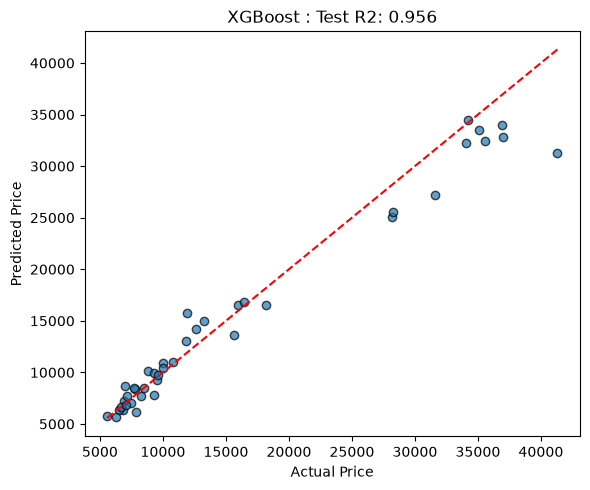

In [48]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_test_pred, alpha=0.7, edgecolor="k")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"XGBoost : Test R2: {round(test_r2, 3)}")
plt.tight_layout()
plt.show()

## Feature Importance:

In [49]:
feature_col = encoding.get_feature_names_out(categorical_column)

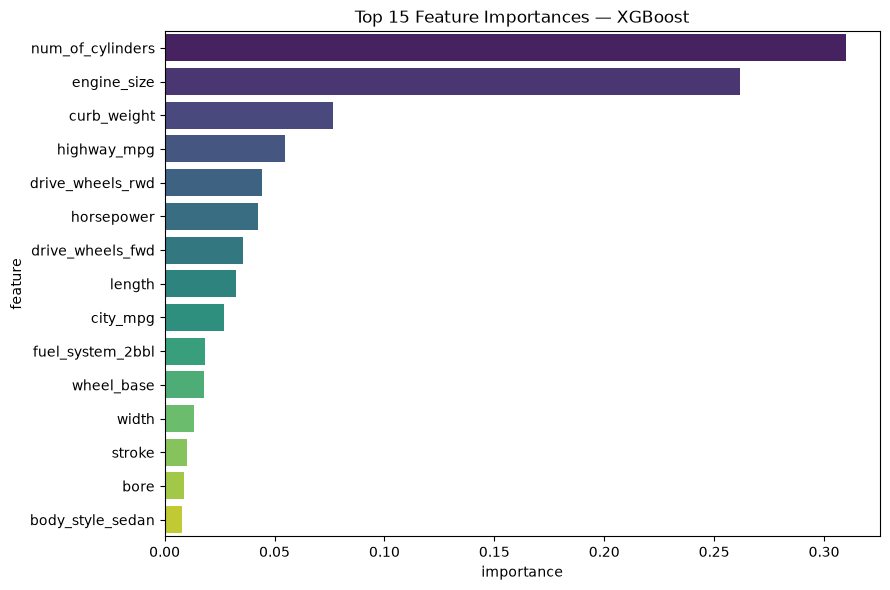

In [50]:
all_features = numerical_column + list(feature_col)

fi_df = pd.DataFrame({
    "feature"   : all_features,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=fi_df, y="feature", x="importance", palette="viridis")
plt.title("Top 15 Feature Importances — XGBoost")
plt.tight_layout()
plt.show()

### saving model

In [51]:
import pickle
with open('car_price_model.pkl','wb') as f:
    pickle.dump(final_model, f)

print('model saved')

model saved


### testing model

In [52]:
with open('car_price_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [53]:
new_car = x_test_final[0].reshape(1, -1)

predicted_price = loaded_model.predict(new_car)
actual_price = y_test.values[0]

print(f'Actual Price : {actual_price}')
print(f'Predicted Price: {round(predicted_price[0])}')
print(f'Difference : {(actual_price - round(predicted_price[0]))}')

Actual Price : 8249
Predicted Price: 7675
Difference : 574


In [54]:
# ek naya car manually banao
new_car_data = pd.DataFrame([{
    "symboling"        : 0,
    "normalized_losses": 100,
    "make"             : "toyota",
    "fuel_type"        : "gas",
    "aspiration"       : "std",
    "num_of_doors"     : 4,
    "body_style"       : "sedan",
    "drive_wheels"     : "fwd",
    "engine_location"  : "front",
    "wheel_base"       : 98.0,
    "length"           : 170.0,
    "width"            : 65.0,
    "height"           : 54.0,
    "curb_weight"      : 2400,
    "engine_type"      : "ohc",
    "num_of_cylinders" : 4,
    "engine_size"      : 110,
    "fuel_system"      : "mpfi",
    "bore"             : 3.19,
    "stroke"           : 3.40,
    "compression_ratio": 10.0,
    "horsepower"       : 102,
    "peak_rpm"         : 5500,
    "city_mpg"         : 24,
    "highway_mpg"      : 30,
}])

# same scaling aur encoding apply karo
new_scaled = scaler.transform(new_car_data[numerical_column])
new_encoder    = encoding.transform(new_car_data[categorical_column])
new_final  = np.hstack([new_scaled, new_encoder])

# predict
price = loaded_model.predict(new_final)
print("Predicted Price: $", round(price[0], 0))

Predicted Price: $ 10346.0


### Linear Regression model

since the r2 score on test set was in minus -


In [55]:
lr_model = LinearRegression()
lr_model.fit(x_train_final, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](67,)","[-134.77, -15.91, 485.97,...,-668.97,-756.87,1591.59]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.155e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,67
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,56
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](67,)","[34.92,23.25,16.54,..., 0. , 0. , 0. ]"


In [56]:
y_pred_lr = lr_model.predict(x_test_final)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

In [57]:
print(f'mean absolute error:  $ {mae_lr:.2f}')
print(f'R-squared score:  $ {r2_lr:.2f}')


mean absolute error:  $ 1721.20
R-squared score:  $ 0.94


In [58]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [59]:
np.set_printoptions(threshold=1000, edgeitems=3, linewidth=75)
x_test_final[1]

array([-0.61494005, -0.16107715, -1.24083945,  0.80417923,  1.64828087,
        1.04556575, -0.05635006,  1.71413632,  1.62749582,  2.12737129,
        1.0862367 ,  0.43888364, -0.53604899,  2.24956591,  0.56624371,
       -1.47371466, -1.31463488,  0.        ,  0.        ,  1.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        1.        ,  1.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
        1.        ,  1.        ,  0.        ,  0.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
        0.        ,  0.        ])

In [60]:

import sys
print(sys.version)

print(x_train_final.shape)
print(x_test_final.shape)

3.11.15 (main, Jun 11 2026, 15:14:57) [Clang 20.1.8 ]
(160, 67)
(41, 67)


In [61]:
type(x_test_final)

numpy.ndarray